# Import Required Libraries

In [62]:
import glob #find all image files in folder
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle # for shuffling

# Read Images Using glob

In [63]:
with_mask = glob.glob(r"C:\Users\Edu_K_61\Desktop\Devika\EDURE\EDURE\DL\Face Mask Detection Project Dataset\with_mask 1\with_mask 1\*.jpg")
without_mask = glob.glob(r"C:\Users\Edu_K_61\Desktop\Devika\EDURE\EDURE\DL\Face Mask Detection Project Dataset\without_mask\without_mask\*.jpg")

In [64]:
len(with_mask)

1696

In [65]:
len(without_mask)

1792

In [66]:
#Create Data and Label Lists
data = []
labels = []

#Read "With Mask" Images
for img_path in with_mask:
    
    img = cv2.imread(img_path)
    
    img = cv2.resize(img,(100,100))
    
    data.append(img)
    
    labels.append(0)

#Read "Without Mask" Images

for img_path in without_mask:
    
    img = cv2.imread(img_path)
    
    img = cv2.resize(img,(100,100))
    
    data.append(img)
    
    labels.append(1)

# Plot some of the images

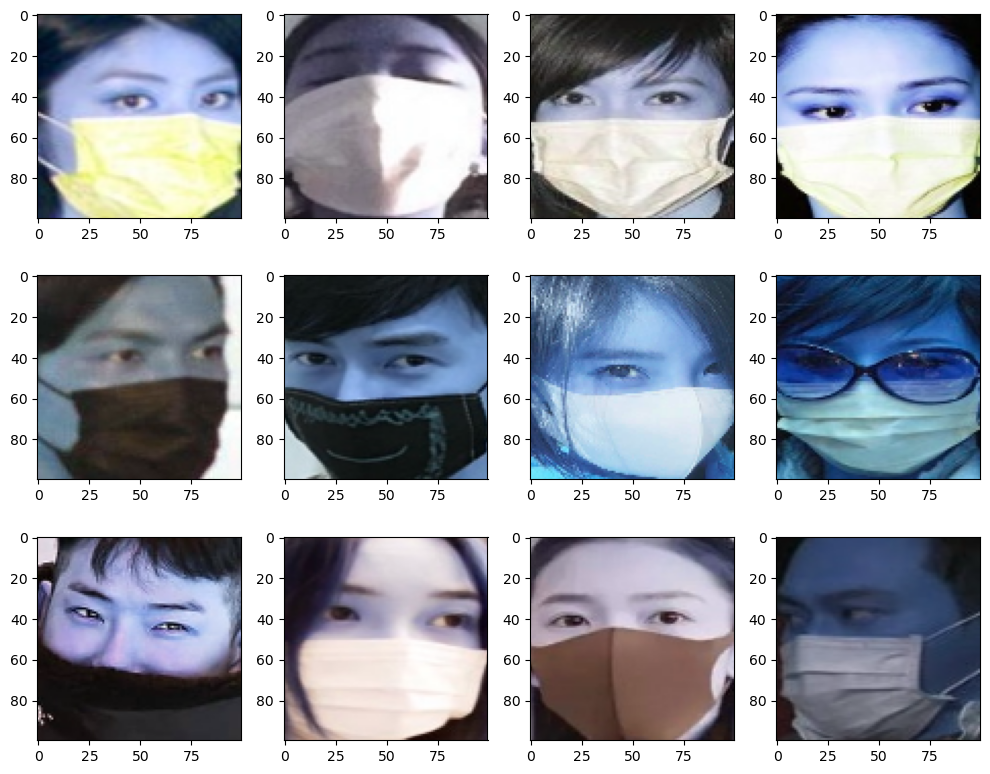

In [67]:
plt.figure(figsize = (10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(data[i])
plt.tight_layout()

# Shuffle Data and labels

In [68]:
data, label = shuffle(data, labels)

# Convert to NumPy Array

In [69]:
data = np.array(data)
labels = np.array(labels)

# Normalization:

In [70]:
data = data / 255.0

# Check Dataset

In [71]:
print("Total Images:",len(data))
print("Shape:",data.shape)

Total Images: 3488
Shape: (3488, 100, 100, 3)


# Plot the images once again

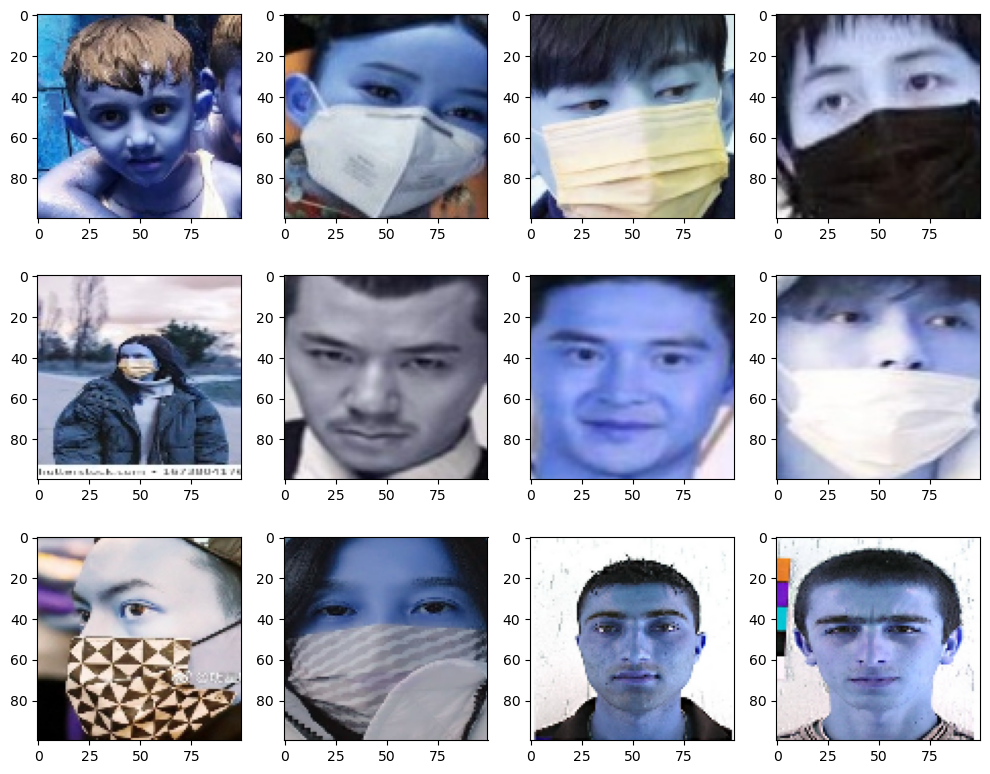

In [72]:
plt.figure(figsize = (10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(data[i])
plt.tight_layout()

# Train Test Split

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

# Convert Labels to Categorical

example
0 → [1,0]   (Mask)
1 → [0,1]   (No Mask)

In [74]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

# Build CNN Model

In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(100,100,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2,activation='softmax'))

# Compile Model

In [76]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate Model

In [77]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - accuracy: 0.5108 - loss: 0.7386 - val_accuracy: 0.5100 - val_loss: 0.6931
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.5204 - loss: 0.6923 - val_accuracy: 0.5086 - val_loss: 0.6935
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 186ms/step - accuracy: 0.5606 - loss: 0.6851 - val_accuracy: 0.4928 - val_loss: 0.7280
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.5896 - loss: 0.6641 - val_accuracy: 0.4986 - val_loss: 0.7111
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 186ms/step - accuracy: 0.6376 - loss: 0.6325 - val_accuracy: 0.5014 - val_loss: 0.7482
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 200ms/step - accuracy: 0.6728 - loss: 0.5857 - val_accuracy: 0.5129 - val_loss: 0.7861
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 186ms/step - accuracy: 0.7179 - loss: 0.5390 - val_accuracy: 0.4928 - val_loss: 0.8504
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 189ms/step - accuracy: 0.7638 - loss: 0.4833 - val_accu

In [78]:
loss, accuracy = model.evaluate(X_test,y_test)

print("Model Accuracy:",accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5043 - loss: 1.1831
Model Accuracy: 0.5042979717254639


# Test with New Image

In [79]:
img = cv2.imread(r"C:\Users\Edu_K_61\Downloads\pexels-ashutoshsonwani-1839564.jpg")

img = cv2.resize(img,(100,100))

img = img/255.0

img = np.reshape(img,(1,100,100,3))

prediction = model.predict(img)

if prediction[0][0] > prediction[0][1]:
    print("Mask Detected")
else:
    print("No Mask")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
No Mask


TypeError: Invalid shape (1, 100, 100, 3) for image data

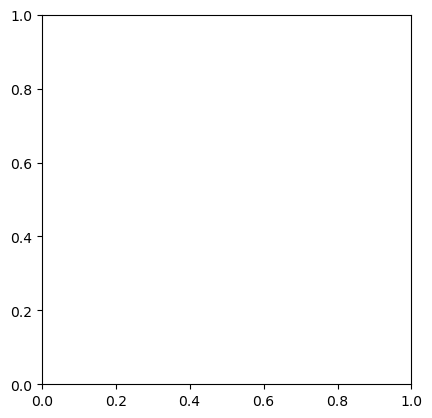

In [80]:
plt.imshow(img)